In [1]:
cd /content/drive/MyDrive/HybridRE/Data

/content/drive/MyDrive/HybridRE/Data


## Threshold impact on cost analysis


In [2]:
import pandas as pd
import scorer
from contextlib import redirect_stdout
import io
from pathlib import Path

# =========================
# CONFIG
# =========================
PLMS = ["PLM_ROBERTA-LARGE"]
SPLIT = "TEST"
DATASETS = ["TACRED", "TACREV", "ReTACRED"]
LLMS = ["LAMA", "Mistral", "QWEEN"]

# Fixed thresholds selected on DEV
FIXED_TAU = {
    "TACRED": 0.80,
    "TACREV": 0.90,
    "ReTACRED": 0.95,
}

BASE_DIR = Path("3_Final_predictions")

# =========================
# UTILS
# =========================
def silent_score(gold, pred):
    f = io.StringIO()
    with redirect_stdout(f):
        p, r, f1 = scorer.score(gold, pred, verbose=False)
    return p, r, f1

# =========================
# EVAL + PRINT
# =========================
for plm in PLMS:
    print("\n" + "=" * 90)
    print(f"PLM: {plm} | SPLIT: {SPLIT}")
    print("=" * 90)

    for dataset in DATASETS:
        tau = FIXED_TAU[dataset]

        print(f"\nDataset: {dataset}  (fixed τ={tau:.2f})")
        print("-" * 90)
        print(f"{'Model':<12}{'P (%)':<10}{'R (%)':<10}{'F1 (%)':<10}")
        print("-" * 90)

        # We compute PLM once per dataset (any existing file gives same PLM preds/gold)
        plm_done = False
        plm_p = plm_r = plm_f1 = None

        for llm in LLMS:
            file = BASE_DIR / dataset / f"{plm}_{dataset}_{SPLIT}_LORA_{llm}.csv"
            if not file.exists():
                print(f"{('LLM-'+llm):<12}{'MISSING':<10}{'':<10}{''}")
                continue

            df = pd.read_csv(file)
            required = {"True_Labels", "Initial_Predictions", "Confidence", "LLM_Prediction"}
            if not required.issubset(df.columns):
                print(f"{('LLM-'+llm):<12}{'BAD_COLS':<10}{'':<10}{''}")
                continue

            gold = df["True_Labels"].tolist()
            plm_pred = df["Initial_Predictions"].tolist()
            llm_pred = df["LLM_Prediction"].tolist()
            conf = df["Confidence"].tolist()

            # ---- PLM only (print once) ----
            if not plm_done:
                p_plm, r_plm, f1_plm = silent_score(gold, plm_pred)
                plm_p, plm_r, plm_f1 = p_plm, r_plm, f1_plm
                print(f"{'PLM':<12}{p_plm*100:<10.3f}{r_plm*100:<10.3f}{f1_plm*100:<10.3f}")
                plm_done = True

            # ---- LLM only ----
            p_llm, r_llm, f1_llm = silent_score(gold, llm_pred)
            print(f"{('LLM-'+llm):<12}{p_llm*100:<10.3f}{r_llm*100:<10.3f}{f1_llm*100:<10.3f}")

            # ---- HybridRE (fixed τ) ----
            hybrid_pred = [p if c >= tau else l for c, p, l in zip(conf, plm_pred, llm_pred)]
            p_h, r_h, f1_h = silent_score(gold, hybrid_pred)
            print(f"{('Hybrid-'+llm):<12}{p_h*100:<10.3f}{r_h*100:<10.3f}{f1_h*100:<10.3f}")

            print("-" * 90)


PLM: PLM_ROBERTA-LARGE | SPLIT: TEST

Dataset: TACRED  (fixed τ=0.80)
------------------------------------------------------------------------------------------
Model       P (%)     R (%)     F1 (%)    
------------------------------------------------------------------------------------------
PLM         74.917    74.286    74.600    
LLM-LAMA    77.820    73.654    75.680    
Hybrid-LAMA 78.515    74.075    76.230    
------------------------------------------------------------------------------------------
LLM-Mistral 77.656    74.316    75.949    
Hybrid-Mistral78.239    74.286    76.211    
------------------------------------------------------------------------------------------
LLM-QWEEN   75.657    76.180    75.918    
Hybrid-QWEEN76.892    75.459    76.169    
------------------------------------------------------------------------------------------

Dataset: TACREV  (fixed τ=0.90)
------------------------------------------------------------------------------------------
Mode

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path

# =========================================================
# CONFIGURATION
# =========================================================

PLM = "PLM_ROBERTA-LARGE"
LLM = "QWEEN"
DATASET = "TACRED"
SPLIT = "DEV"

BASE_DIR = Path("3_Final_predictions")

# Thresholds to display in the table
# Full PLM is added separately with tau = 0.00
# Add 1.001 to guarantee 100% LLM routing with rule: confidence < tau
THRESHOLDS = np.append(np.round(np.arange(0.60, 1.001, 0.01), 2), 1.001)

# =========================================================
# LATENCY MODEL (SECONDS / INSTANCE)
# =========================================================

LATENCY = {
    "plm": 0.0042,
    "llm": 0.0776,
}

# =========================================================
# API PRICING (USD PER 1M TOKENS)
# =========================================================

PRICING = {

    "together": {
        "qwen2_5_7b_instruct": {"in": 0.30, "out": 0.30},
        "llama3_1_8b_instruct": {"in": 0.18, "out": 0.18},
        "mistral_7b_instruct_v03": {"in": 0.20, "out": 0.20},
    },

    "fireworks": {
        "qwen2_5_7b_instruct": {"in": 0.20, "out": 0.20},
        "llama3_1_8b_instruct": {"in": 0.20, "out": 0.20},
        "mistral_7b_instruct_v03": {"in": 0.20, "out": 0.20},
    },

}

PLATFORM = "together"
API = "qwen2_5_7b_instruct"
AVG_INPUT_TOKENS = 100
AVG_OUTPUT_TOKENS = 1

# =========================================================
# CONSTRAINTS
# =========================================================

TMAX = 0.020      # seconds / instance
BUDGET_1M = 10   # USD / 1M processed instances

# =========================================================
# SAVE OPTIONS
# =========================================================

SAVE_TABLE_CSV = True

# =========================================================
# HELPERS
# =========================================================

def get_prediction_file() -> Path:
    """
    Expected file:
    3_Final_predictions/ReTACRED/PLM_ROBERTA-LARGE_ReTACRED_DEV_LORA_QWEEN.csv
    """
    return BASE_DIR / DATASET / f"{PLM}_{DATASET}_{SPLIT}_LORA_{LLM}.csv"


def load_confidences() -> np.ndarray:
    """
    Load confidence scores.
    Routing rule:
        route to LLM if confidence < tau
    """
    file_path = get_prediction_file()

    if not file_path.exists():
        raise FileNotFoundError(f"Missing file: {file_path}")

    df = pd.read_csv(file_path)

    if "Confidence" not in df.columns:
        raise ValueError(f"'Confidence' column not found in {file_path}")

    return df["Confidence"].to_numpy(dtype=float)


def routing_rate(confidences: np.ndarray, tau: float) -> float:
    """
    alpha(tau): proportion of examples routed to the LLM.
    """
    return float(np.mean(confidences < tau))


def hybrid_latency(alpha: float) -> float:
    """
    HybridRE latency model:
        T_hybrid = T_plm + alpha * T_llm
    """
    return LATENCY["plm"] + alpha * LATENCY["llm"]


def hybrid_cost_per_instance(alpha: float) -> float:
    """
    Expected monetary cost per instance.
    """
    price_in = PRICING[PLATFORM][API]["in"] / 1_000_000.0
    price_out = PRICING[PLATFORM][API]["out"] / 1_000_000.0

    return alpha * (
        AVG_INPUT_TOKENS * price_in +
        AVG_OUTPUT_TOKENS * price_out
    )


def build_row(confidences: np.ndarray, tau: float, label: str = "") -> dict:
    """
    Build one output row for a given threshold.
    """
    alpha = routing_rate(confidences, tau)
    pct_llm = alpha * 100.0
    latency = hybrid_latency(alpha)
    cost_1m = hybrid_cost_per_instance(alpha) * 1_000_000

    return {
        "label": label if label else (f"tau={tau:.3f}" if tau > 1 else f"tau={tau:.2f}"),
        "tau": float(tau),
        "pct_llm_reclassified": pct_llm,
        "avg_latency_sec": latency,
        "cost_per_1M_usd": cost_1m,
    }


def find_largest_feasible_tau(confidences: np.ndarray, mode: str):
    """
    Return the largest threshold in the displayed grid satisfying:
    - latency <= TMAX, if mode='latency'
    - cost <= BUDGET_1M, if mode='budget'
    """
    feasible = []

    for tau in THRESHOLDS:
        alpha = routing_rate(confidences, tau)
        latency = hybrid_latency(alpha)
        cost_1m = hybrid_cost_per_instance(alpha) * 1_000_000

        if mode == "latency" and latency <= TMAX:
            feasible.append((tau, alpha, latency, cost_1m))
        elif mode == "budget" and cost_1m <= BUDGET_1M:
            feasible.append((tau, alpha, latency, cost_1m))

    if not feasible:
        return None

    return max(feasible, key=lambda x: x[0])


def fmt(x, digits=4):
    return round(float(x), digits)

# =========================================================
# MAIN
# =========================================================

confidences = load_confidences()
rows = []

# Full PLM
rows.append(build_row(confidences, 0.00, label="Full PLM"))

# Thresholds from 0.70 to 1.00
for tau in THRESHOLDS:
    if tau < 1.001:
        rows.append(build_row(confidences, tau))

# Full LLM (guaranteed 100%)
rows.append(build_row(confidences, 1.001, label="Full LLM"))

# Budget-based selections
best_latency = find_largest_feasible_tau(confidences, mode="latency")
best_budget = find_largest_feasible_tau(confidences, mode="budget")

if best_latency is not None:
    rows.append({
        "label": "Chosen by TMAX",
        "tau": float(best_latency[0]),
        "pct_llm_reclassified": best_latency[1] * 100.0,
        "avg_latency_sec": best_latency[2],
        "cost_per_1M_usd": best_latency[3],
    })

if best_budget is not None:
    rows.append({
        "label": "Chosen by Budget",
        "tau": float(best_budget[0]),
        "pct_llm_reclassified": best_budget[1] * 100.0,
        "avg_latency_sec": best_budget[2],
        "cost_per_1M_usd": best_budget[3],
    })

result_df = pd.DataFrame(rows)

# =========================================================
# DISPLAY
# =========================================================

display_df = result_df.copy()
display_df["pct_llm_reclassified"] = display_df["pct_llm_reclassified"].map(lambda x: fmt(x, 2))
display_df["avg_latency_sec"] = display_df["avg_latency_sec"].map(lambda x: fmt(x, 4))
display_df["cost_per_1M_usd"] = display_df["cost_per_1M_usd"].map(lambda x: fmt(x, 2))

print("\n" + "=" * 95)
print(f"HYBRIDRE COST-AWARE THRESHOLD TABLE | DATASET={DATASET} | PLM={PLM} | LLM={LLM}")
print("=" * 95)
print(f"PLM latency: {LATENCY['plm']:.4f} s/instance")
print(f"LLM latency: {LATENCY['llm']:.4f} s/instance")
print(f"Platform: {PLATFORM}")
print(f"API: {API}")
print(f"Average tokens per routed call: input={AVG_INPUT_TOKENS}, output={AVG_OUTPUT_TOKENS}")
print(f"TMAX: {TMAX:.3f} s/instance | Budget: ${BUDGET_1M:.2f} / 1M")
print("-" * 95)
print(display_df.to_string(index=False))

# =========================================================
# SAVE
# =========================================================

if SAVE_TABLE_CSV:
    out_path = BASE_DIR / DATASET / f"COST_AWARE_THRESHOLDS_{PLM}_{LLM}_{SPLIT}.csv"
    result_df.to_csv(out_path, index=False)
    print(f"\n[Saved] {out_path}")


HYBRIDRE COST-AWARE THRESHOLD TABLE | DATASET=TACRED | PLM=PLM_ROBERTA-LARGE | LLM=QWEEN
PLM latency: 0.0042 s/instance
LLM latency: 0.0776 s/instance
Platform: together
API: qwen2_5_7b_instruct
Average tokens per routed call: input=100, output=1
TMAX: 0.020 s/instance | Budget: $10.00 / 1M
-----------------------------------------------------------------------------------------------
           label   tau  pct_llm_reclassified  avg_latency_sec  cost_per_1M_usd
        Full PLM 0.000                  0.00           0.0042             0.00
        tau=0.60 0.600                  5.20           0.0082             1.57
        tau=0.61 0.610                  5.65           0.0086             1.71
        tau=0.62 0.620                  6.05           0.0089             1.83
        tau=0.63 0.630                  6.54           0.0093             1.98
        tau=0.64 0.640                  6.93           0.0096             2.10
        tau=0.65 0.650                  7.41           0.0

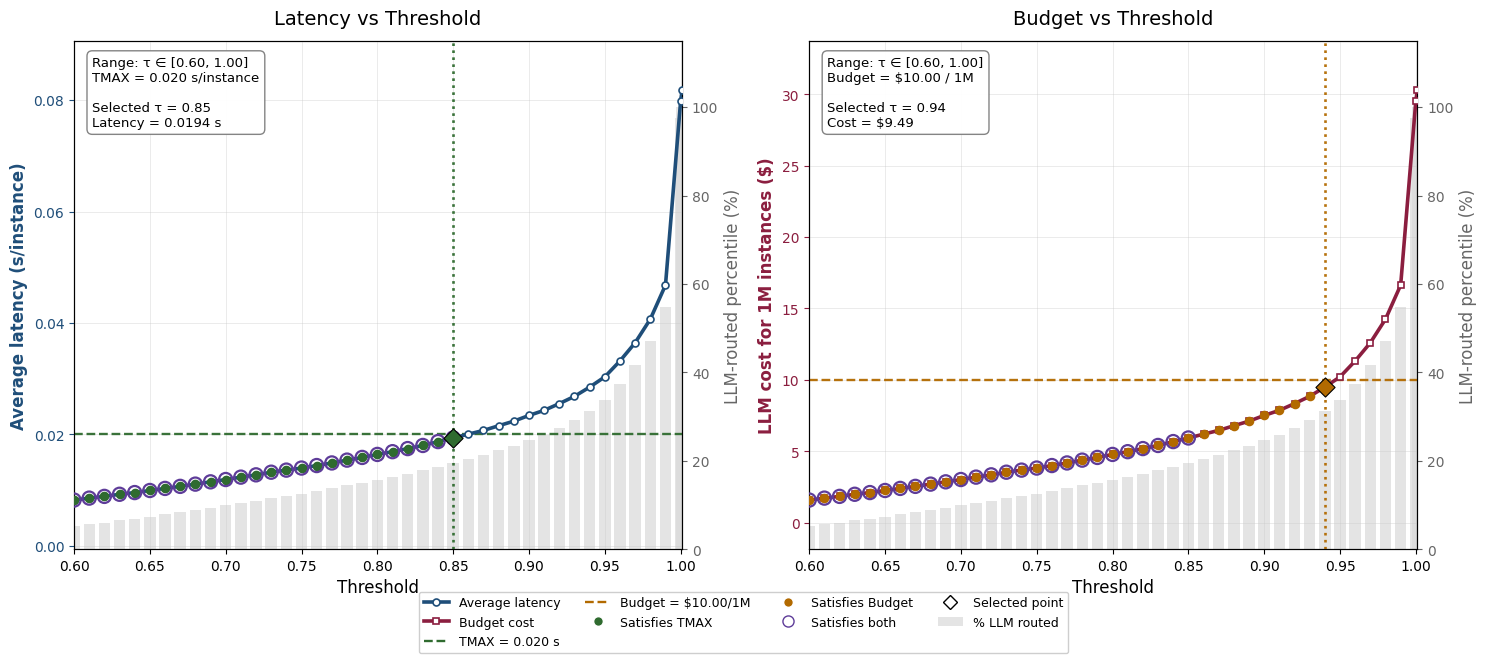

[Saved] FINAL_THRESHOLD_TWO_PANEL_PLM_ROBERTA-LARGE_QWEEN_DEV.png
[Saved] FINAL_THRESHOLD_TWO_PANEL_PLM_ROBERTA-LARGE_QWEEN_DEV.pdf


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from matplotlib.lines import Line2D

# =========================================================
# INPUT
# =========================================================
# result_df must already exist with columns:
# label, tau, pct_llm_reclassified, avg_latency_sec, cost_per_1M_usd

OUT_DIR = BASE_DIR / DATASET
OUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================================================
# PREPARE DATA
# =========================================================
df = result_df.copy()

curve_df = df[
    df["label"].isin(["Full PLM", "Full LLM"]) | df["label"].str.startswith("tau=")
].copy()

curve_df = curve_df.sort_values("tau").reset_index(drop=True)

# Focus region
TAU_MIN = 0.60
TAU_MAX = 1.001

focus_df = curve_df[
    (curve_df["tau"] >= TAU_MIN) &
    (curve_df["tau"] <= TAU_MAX)
].copy().reset_index(drop=True)

# Feasibility flags
focus_df["budget_ok"] = focus_df["cost_per_1M_usd"] <= BUDGET_1M
focus_df["tmax_ok"] = focus_df["avg_latency_sec"] <= TMAX
focus_df["both_ok"] = focus_df["budget_ok"] & focus_df["tmax_ok"]

# Selected thresholds
tmax_row = df[df["label"] == "Chosen by TMAX"]
budget_row = df[df["label"] == "Chosen by Budget"]

tau_tmax = float(tmax_row["tau"].iloc[0]) if not tmax_row.empty else None
tau_budget = float(budget_row["tau"].iloc[0]) if not budget_row.empty else None

# =========================================================
# STYLE
# =========================================================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
})

# Springer/LNCS-like colors
COLOR_TIME = "#1f4e79"       # deep blue
COLOR_BUDGET = "#8b1e3f"     # burgundy
COLOR_TMAX = "#2f6b2f"       # dark green
COLOR_BUDGET_OK = "#b26a00"  # amber
COLOR_BOTH = "#5e3c99"       # violet
COLOR_BAR = "#d9d9d9"        # light gray
COLOR_GRID = "#c7c7c7"
COLOR_BOX_EDGE = "#7f7f7f"

# =========================================================
# BAR WIDTH
# =========================================================
if len(focus_df) > 1:
    step = np.median(np.diff(focus_df["tau"]))
    bar_width = step * 0.75
else:
    bar_width = 0.008

# =========================================================
# FIGURE: 2 PANELS IN ONE ROW
# =========================================================
fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 6.6), sharex=True)

# twin axes for bars
axL_bar = axL.twinx()
axR_bar = axR.twinx()

# keep bars behind lines
axL_bar.set_zorder(0)
axR_bar.set_zorder(0)
axL.set_zorder(2)
axR.set_zorder(2)
axL.patch.set_alpha(0.0)
axR.patch.set_alpha(0.0)

# =========================================================
# LEFT PANEL: LATENCY + ROUTED %
# =========================================================
barsL = axL_bar.bar(
    focus_df["tau"],
    focus_df["pct_llm_reclassified"],
    width=bar_width,
    color=COLOR_BAR,
    edgecolor="none",
    alpha=0.7,
    label="% LLM routed",
    zorder=1
)

line_time, = axL.plot(
    focus_df["tau"],
    focus_df["avg_latency_sec"],
    color=COLOR_TIME,
    linewidth=2.6,
    marker="o",
    markersize=5,
    markerfacecolor="white",
    markeredgewidth=1.2,
    label="Average latency",
    zorder=4
)

# feasible points on latency curve
tmax_pts = focus_df[focus_df["tmax_ok"]]
axL.scatter(
    tmax_pts["tau"],
    tmax_pts["avg_latency_sec"],
    color=COLOR_TMAX,
    s=35,
    zorder=5
)

both_pts = focus_df[focus_df["both_ok"]]
if len(both_pts) > 0:
    axL.scatter(
        both_pts["tau"],
        both_pts["avg_latency_sec"],
        facecolors="none",
        edgecolors=COLOR_BOTH,
        s=90,
        linewidths=1.6,
        zorder=6
    )

h_tmax = axL.axhline(
    TMAX,
    color=COLOR_TMAX,
    linestyle="--",
    linewidth=1.7,
    alpha=0.95,
    label=f"TMAX = {TMAX:.3f} s"
)

if tau_tmax is not None and TAU_MIN <= tau_tmax <= TAU_MAX:
    axL.axvline(
        tau_tmax,
        color=COLOR_TMAX,
        linestyle=":",
        linewidth=1.9,
        alpha=0.95
    )
    y_tmax_time = float(tmax_row["avg_latency_sec"].iloc[0])
    axL.scatter(
        [tau_tmax], [y_tmax_time],
        color=COLOR_TMAX, marker="D", s=95,
        edgecolors="black", linewidths=0.8, zorder=7
    )

# =========================================================
# RIGHT PANEL: BUDGET + ROUTED %
# =========================================================
barsR = axR_bar.bar(
    focus_df["tau"],
    focus_df["pct_llm_reclassified"],
    width=bar_width,
    color=COLOR_BAR,
    edgecolor="none",
    alpha=0.7,
    label="% LLM routed",
    zorder=1
)

line_budget, = axR.plot(
    focus_df["tau"],
    focus_df["cost_per_1M_usd"],
    color=COLOR_BUDGET,
    linewidth=2.6,
    marker="s",
    markersize=5,
    markerfacecolor="white",
    markeredgewidth=1.2,
    label="Budget cost",
    zorder=4
)

# feasible points on budget curve
budget_pts = focus_df[focus_df["budget_ok"]]
axR.scatter(
    budget_pts["tau"],
    focus_df.loc[budget_pts.index, "cost_per_1M_usd"],
    color=COLOR_BUDGET_OK,
    s=35,
    zorder=5
)

if len(both_pts) > 0:
    axR.scatter(
        both_pts["tau"],
        both_pts["cost_per_1M_usd"],
        facecolors="none",
        edgecolors=COLOR_BOTH,
        s=90,
        linewidths=1.6,
        zorder=6
    )

h_budget = axR.axhline(
    BUDGET_1M,
    color=COLOR_BUDGET_OK,
    linestyle="--",
    linewidth=1.7,
    alpha=0.95,
    label=f"Budget = ${BUDGET_1M:.2f}/1M"
)

if tau_budget is not None and TAU_MIN <= tau_budget <= TAU_MAX:
    axR.axvline(
        tau_budget,
        color=COLOR_BUDGET_OK,
        linestyle=":",
        linewidth=1.9,
        alpha=0.95
    )
    y_budget_cost = float(budget_row["cost_per_1M_usd"].iloc[0])
    axR.scatter(
        [tau_budget], [y_budget_cost],
        color=COLOR_BUDGET_OK, marker="D", s=95,
        edgecolors="black", linewidths=0.8, zorder=7
    )

# =========================================================
# AXES FORMATTING
# =========================================================
for ax in [axL, axR]:
    ax.set_xlim(TAU_MIN, TAU_MAX)
    ax.set_xticks(np.arange(TAU_MIN, TAU_MAX + 0.001, 0.05))
    ax.grid(True, linestyle="-", linewidth=0.7, alpha=0.35, color=COLOR_GRID)
    ax.set_xlabel("Threshold")

axL.set_title("Latency vs Threshold", pad=12)
axR.set_title("Budget vs Threshold", pad=12)

axL.set_ylabel("Average latency (s/instance)", color=COLOR_TIME, fontweight="bold")
axR.set_ylabel("LLM cost for 1M instances ($)", color=COLOR_BUDGET, fontweight="bold")

axL.tick_params(axis="y", colors=COLOR_TIME)
axR.tick_params(axis="y", colors=COLOR_BUDGET)

# bar axes
for axb in [axL_bar, axR_bar]:
    axb.set_ylabel("LLM-routed percentile (%)", color="#666666")
    axb.tick_params(axis="y", colors="#666666")
    bar_max = max(5, focus_df["pct_llm_reclassified"].max() * 1.15)
    axb.set_ylim(0, bar_max)

# main y-scales
lat_min = focus_df["avg_latency_sec"].min()
lat_max = max(focus_df["avg_latency_sec"].max(), TMAX)
lat_pad = (lat_max - lat_min) * 0.12 if lat_max > lat_min else 0.001
axL.set_ylim(lat_min - lat_pad, lat_max + lat_pad)

cost_min = focus_df["cost_per_1M_usd"].min()
cost_max = max(focus_df["cost_per_1M_usd"].max(), BUDGET_1M)
cost_pad = (cost_max - cost_min) * 0.12 if cost_max > cost_min else 0.05
axR.set_ylim(cost_min - cost_pad, cost_max + cost_pad)

# =========================================================
# SEPARATE INFO BOXES
# =========================================================
left_box_lines = [
    f"Range: τ ∈ [{TAU_MIN:.2f}, {TAU_MAX:.2f}]",
    f"TMAX = {TMAX:.3f} s/instance",
]

if tau_tmax is not None:
    left_box_lines += [
        "",
        f"Selected τ = {tau_tmax:.2f}",
        f"Latency = {float(tmax_row['avg_latency_sec'].iloc[0]):.4f} s",
    ]

axL.text(
    0.03, 0.97,
    "\n".join(left_box_lines),
    transform=axL.transAxes,
    ha="left",
    va="top",
    fontsize=9.5,
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor=COLOR_BOX_EDGE,
        alpha=0.96
    )
)

right_box_lines = [
    f"Range: τ ∈ [{TAU_MIN:.2f}, {TAU_MAX:.2f}]",
    f"Budget = ${BUDGET_1M:.2f} / 1M",
]

if tau_budget is not None:
    right_box_lines += [
        "",
        f"Selected τ = {tau_budget:.2f}",
        f"Cost = ${float(budget_row['cost_per_1M_usd'].iloc[0]):.2f}",
    ]

axR.text(
    0.03, 0.97,
    "\n".join(right_box_lines),
    transform=axR.transAxes,
    ha="left",
    va="top",
    fontsize=9.5,
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor=COLOR_BOX_EDGE,
        alpha=0.96
    )
)

# =========================================================
# GLOBAL LEGEND
# =========================================================
custom_handles = [
    Line2D([0], [0], color=COLOR_TIME, lw=2.6, marker='o', markersize=5,
           markerfacecolor="white", markeredgewidth=1.2, label='Average latency'),
    Line2D([0], [0], color=COLOR_BUDGET, lw=2.6, marker='s', markersize=5,
           markerfacecolor="white", markeredgewidth=1.2, label='Budget cost'),
    Line2D([0], [0], color=COLOR_TMAX, lw=1.7, linestyle='--', label=f'TMAX = {TMAX:.3f} s'),
    Line2D([0], [0], color=COLOR_BUDGET_OK, lw=1.7, linestyle='--', label=f'Budget = ${BUDGET_1M:.2f}/1M'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COLOR_TMAX, markersize=7, label='Satisfies TMAX'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COLOR_BUDGET_OK, markersize=7, label='Satisfies Budget'),
    Line2D([0], [0], marker='o', color=COLOR_BOTH, markerfacecolor='none', markersize=8, lw=0, label='Satisfies both'),
    Line2D([0], [0], marker='D', color='black', markerfacecolor='white', markersize=7, lw=0, label='Selected point'),
    plt.Rectangle((0, 0), 1, 1, fc=COLOR_BAR, alpha=0.7, label='% LLM routed'),
]

fig.legend(
    handles=custom_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.01),
    ncol=4,
    frameon=True,
    facecolor="white",
    framealpha=0.96
)

# =========================================================
# LAYOUT + SAVE
# =========================================================
plt.tight_layout(rect=[0, 0.06, 1, 1])

fig_path_png = f"FINAL_THRESHOLD_TWO_PANEL_{PLM}_{LLM}_{SPLIT}.png"
fig_path_pdf = f"FINAL_THRESHOLD_TWO_PANEL_{PLM}_{LLM}_{SPLIT}.pdf"

plt.savefig(fig_path_png, dpi=300, bbox_inches="tight")
plt.savefig(fig_path_pdf, bbox_inches="tight")
plt.show()

print(f"[Saved] {fig_path_png}")
print(f"[Saved] {fig_path_pdf}")

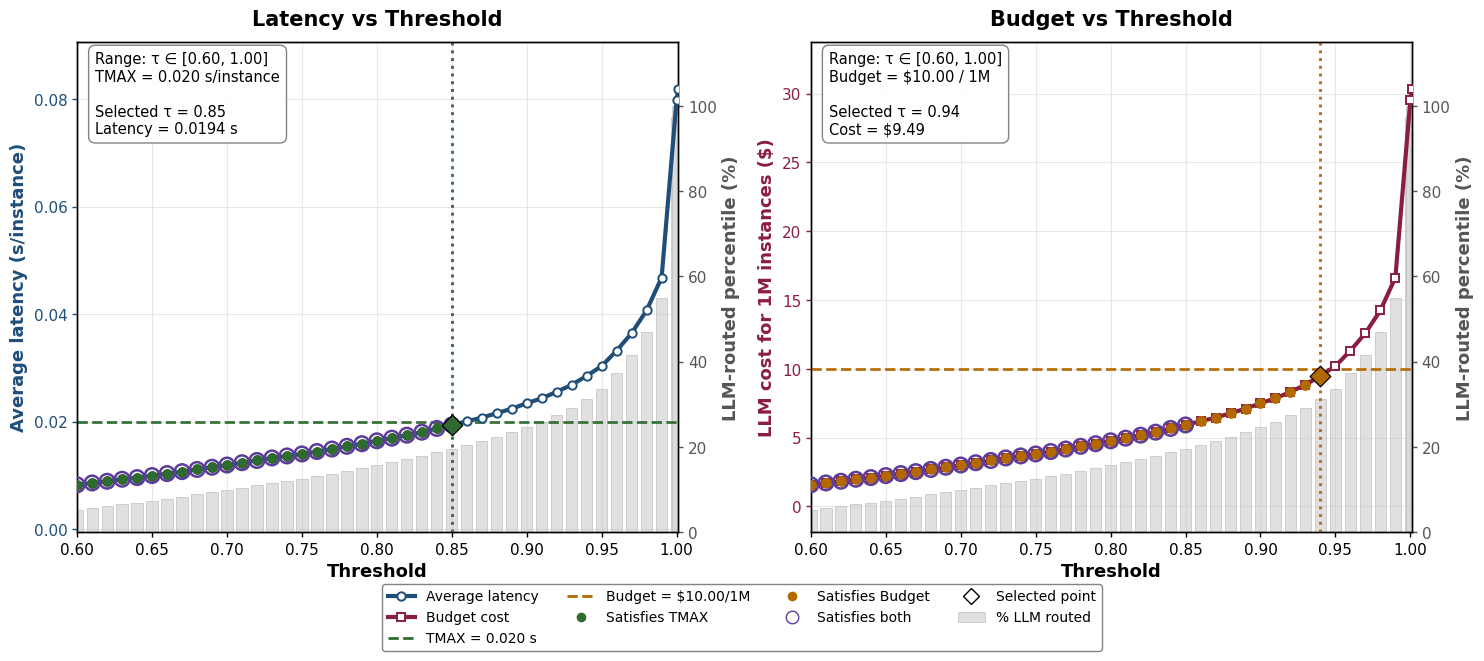

[Saved] FINAL_THRESHOLD_TWO_PANEL_PLM_ROBERTA-LARGE_QWEEN_DEV.png
[Saved] FINAL_THRESHOLD_TWO_PANEL_PLM_ROBERTA-LARGE_QWEEN_DEV.pdf


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from matplotlib.lines import Line2D

# =========================================================
# INPUT
# =========================================================
# result_df must already exist with columns:
# label, tau, pct_llm_reclassified, avg_latency_sec, cost_per_1M_usd

OUT_DIR = BASE_DIR / DATASET
OUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================================================
# PREPARE DATA
# =========================================================
df = result_df.copy()

curve_df = df[
    df["label"].isin(["Full PLM", "Full LLM"]) | df["label"].str.startswith("tau=")
].copy()

curve_df = curve_df.sort_values("tau").reset_index(drop=True)

# Focus region
TAU_MIN = 0.60
TAU_MAX = 1.001

focus_df = curve_df[
    (curve_df["tau"] >= TAU_MIN) &
    (curve_df["tau"] <= TAU_MAX)
].copy().reset_index(drop=True)

# Feasibility flags
focus_df["budget_ok"] = focus_df["cost_per_1M_usd"] <= BUDGET_1M
focus_df["tmax_ok"] = focus_df["avg_latency_sec"] <= TMAX
focus_df["both_ok"] = focus_df["budget_ok"] & focus_df["tmax_ok"]

# Selected thresholds
tmax_row = df[df["label"] == "Chosen by TMAX"]
budget_row = df[df["label"] == "Chosen by Budget"]

tau_tmax = float(tmax_row["tau"].iloc[0]) if not tmax_row.empty else None
tau_budget = float(budget_row["tau"].iloc[0]) if not budget_row.empty else None

# =========================================================
# STYLE
# =========================================================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 13,
    "axes.labelweight": "bold",
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
})

# Springer/LNCS-like colors
COLOR_TIME = "#1f4e79"       # deep blue
COLOR_BUDGET = "#8b1e3f"     # burgundy
COLOR_TMAX = "#2f6b2f"       # dark green
COLOR_BUDGET_OK = "#b26a00"  # amber
COLOR_BOTH = "#5e3c99"       # violet
COLOR_BAR = "#d9d9d9"        # light gray
COLOR_GRID = "#c7c7c7"
COLOR_BOX_EDGE = "#7f7f7f"

# =========================================================
# BAR WIDTH
# =========================================================
if len(focus_df) > 1:
    step = np.median(np.diff(focus_df["tau"]))
    bar_width = step * 0.75
else:
    bar_width = 0.008

# =========================================================
# FIGURE: 2 PANELS IN ONE ROW
# =========================================================
fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 6.6), sharex=True)

# twin axes for bars
axL_bar = axL.twinx()
axR_bar = axR.twinx()

# keep bars behind lines
axL_bar.set_zorder(0)
axR_bar.set_zorder(0)
axL.set_zorder(2)
axR.set_zorder(2)
axL.patch.set_alpha(0.0)
axR.patch.set_alpha(0.0)

# =========================================================
# LEFT PANEL: LATENCY + ROUTED %
# =========================================================
barsL = axL_bar.bar(
    focus_df["tau"],
    focus_df["pct_llm_reclassified"],
    width=bar_width,
    color=COLOR_BAR,
    edgecolor="#b5b5b5",
    linewidth=0.5,
    alpha=0.8,
    label="% LLM routed",
    zorder=1
)

line_time, = axL.plot(
    focus_df["tau"],
    focus_df["avg_latency_sec"],
    color=COLOR_TIME,
    linewidth=3.0,
    marker="o",
    markersize=6,
    markerfacecolor="white",
    markeredgewidth=1.4,
    label="Average latency",
    zorder=4
)

# feasible points on latency curve
tmax_pts = focus_df[focus_df["tmax_ok"]]
axL.scatter(
    tmax_pts["tau"],
    tmax_pts["avg_latency_sec"],
    color=COLOR_TMAX,
    s=45,
    zorder=5
)

both_pts = focus_df[focus_df["both_ok"]]
if len(both_pts) > 0:
    axL.scatter(
        both_pts["tau"],
        both_pts["avg_latency_sec"],
        facecolors="none",
        edgecolors=COLOR_BOTH,
        s=110,
        linewidths=1.8,
        zorder=6
    )

h_tmax = axL.axhline(
    TMAX,
    color=COLOR_TMAX,
    linestyle="--",
    linewidth=2.0,
    alpha=0.95,
    label=f"TMAX = {TMAX:.3f} s"
)

if tau_tmax is not None and TAU_MIN <= tau_tmax <= TAU_MAX:
    axL.axvline(
        tau_tmax,
        color=COLOR_TMAX,
        linestyle=":",
        linewidth=2.1,
        alpha=0.95
    )
    y_tmax_time = float(tmax_row["avg_latency_sec"].iloc[0])
    axL.scatter(
        [tau_tmax], [y_tmax_time],
        color=COLOR_TMAX, marker="D", s=110,
        edgecolors="black", linewidths=0.9, zorder=7
    )

# =========================================================
# RIGHT PANEL: BUDGET + ROUTED %
# =========================================================
barsR = axR_bar.bar(
    focus_df["tau"],
    focus_df["pct_llm_reclassified"],
    width=bar_width,
    color=COLOR_BAR,
    edgecolor="#b5b5b5",
    linewidth=0.5,
    alpha=0.8,
    label="% LLM routed",
    zorder=1
)

line_budget, = axR.plot(
    focus_df["tau"],
    focus_df["cost_per_1M_usd"],
    color=COLOR_BUDGET,
    linewidth=3.0,
    marker="s",
    markersize=6,
    markerfacecolor="white",
    markeredgewidth=1.4,
    label="Budget cost",
    zorder=4
)

# feasible points on budget curve
budget_pts = focus_df[focus_df["budget_ok"]]
axR.scatter(
    budget_pts["tau"],
    focus_df.loc[budget_pts.index, "cost_per_1M_usd"],
    color=COLOR_BUDGET_OK,
    s=45,
    zorder=5
)

if len(both_pts) > 0:
    axR.scatter(
        both_pts["tau"],
        both_pts["cost_per_1M_usd"],
        facecolors="none",
        edgecolors=COLOR_BOTH,
        s=110,
        linewidths=1.8,
        zorder=6
    )

h_budget = axR.axhline(
    BUDGET_1M,
    color=COLOR_BUDGET_OK,
    linestyle="--",
    linewidth=2.0,
    alpha=0.95,
    label=f"Budget = ${BUDGET_1M:.2f}/1M"
)

if tau_budget is not None and TAU_MIN <= tau_budget <= TAU_MAX:
    axR.axvline(
        tau_budget,
        color=COLOR_BUDGET_OK,
        linestyle=":",
        linewidth=2.1,
        alpha=0.95
    )
    y_budget_cost = float(budget_row["cost_per_1M_usd"].iloc[0])
    axR.scatter(
        [tau_budget], [y_budget_cost],
        color=COLOR_BUDGET_OK, marker="D", s=110,
        edgecolors="black", linewidths=0.9, zorder=7
    )

# =========================================================
# AXES FORMATTING
# =========================================================
for ax in [axL, axR]:
    ax.set_xlim(TAU_MIN, TAU_MAX)
    ax.set_xticks(np.arange(TAU_MIN, TAU_MAX + 0.001, 0.05))
    ax.grid(True, linestyle="-", linewidth=0.8, alpha=0.4, color=COLOR_GRID)
    ax.set_xlabel("Threshold", fontweight="bold")
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

axL.set_title("Latency vs Threshold", pad=12)
axR.set_title("Budget vs Threshold", pad=12)

axL.set_ylabel("Average latency (s/instance)", color=COLOR_TIME, fontweight="bold")
axR.set_ylabel("LLM cost for 1M instances ($)", color=COLOR_BUDGET, fontweight="bold")

axL.tick_params(axis="y", colors=COLOR_TIME, width=1.0)
axR.tick_params(axis="y", colors=COLOR_BUDGET, width=1.0)
axL.tick_params(axis="x", width=1.0)
axR.tick_params(axis="x", width=1.0)

# bar axes
for axb in [axL_bar, axR_bar]:
    axb.set_ylabel("LLM-routed percentile (%)", color="#555555", fontweight="bold")
    axb.tick_params(axis="y", colors="#555555", width=1.0)
    bar_max = max(5, focus_df["pct_llm_reclassified"].max() * 1.15)
    axb.set_ylim(0, bar_max)
    for spine in axb.spines.values():
        spine.set_linewidth(1.0)

# main y-scales
lat_min = focus_df["avg_latency_sec"].min()
lat_max = max(focus_df["avg_latency_sec"].max(), TMAX)
lat_pad = (lat_max - lat_min) * 0.12 if lat_max > lat_min else 0.001
axL.set_ylim(lat_min - lat_pad, lat_max + lat_pad)

cost_min = focus_df["cost_per_1M_usd"].min()
cost_max = max(focus_df["cost_per_1M_usd"].max(), BUDGET_1M)
cost_pad = (cost_max - cost_min) * 0.12 if cost_max > cost_min else 0.05
axR.set_ylim(cost_min - cost_pad, cost_max + cost_pad)

# =========================================================
# SEPARATE INFO BOXES
# =========================================================
left_box_lines = [
    f"Range: τ ∈ [{TAU_MIN:.2f}, {TAU_MAX:.2f}]",
    f"TMAX = {TMAX:.3f} s/instance",
]

if tau_tmax is not None:
    left_box_lines += [
        "",
        f"Selected τ = {tau_tmax:.2f}",
        f"Latency = {float(tmax_row['avg_latency_sec'].iloc[0]):.4f} s",
    ]

axL.text(
    0.03, 0.98,
    "\n".join(left_box_lines),
    transform=axL.transAxes,
    ha="left",
    va="top",
    fontsize=10.5,
    fontweight="medium",
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor="white",
        edgecolor=COLOR_BOX_EDGE,
        linewidth=1.0,
        alpha=0.97
    )
)

right_box_lines = [
    f"Range: τ ∈ [{TAU_MIN:.2f}, {TAU_MAX:.2f}]",
    f"Budget = ${BUDGET_1M:.2f} / 1M",
]

if tau_budget is not None:
    right_box_lines += [
        "",
        f"Selected τ = {tau_budget:.2f}",
        f"Cost = ${float(budget_row['cost_per_1M_usd'].iloc[0]):.2f}",
    ]

axR.text(
    0.03, 0.98,
    "\n".join(right_box_lines),
    transform=axR.transAxes,
    ha="left",
    va="top",
    fontsize=10.5,
    fontweight="medium",
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor="white",
        edgecolor=COLOR_BOX_EDGE,
        linewidth=1.0,
        alpha=0.97
    )
)

# =========================================================
# GLOBAL LEGEND
# =========================================================
custom_handles = [
    Line2D([0], [0], color=COLOR_TIME, lw=3.0, marker='o', markersize=6,
           markerfacecolor="white", markeredgewidth=1.4, label='Average latency'),
    Line2D([0], [0], color=COLOR_BUDGET, lw=3.0, marker='s', markersize=6,
           markerfacecolor="white", markeredgewidth=1.4, label='Budget cost'),
    Line2D([0], [0], color=COLOR_TMAX, lw=2.0, linestyle='--', label=f'TMAX = {TMAX:.3f} s'),
    Line2D([0], [0], color=COLOR_BUDGET_OK, lw=2.0, linestyle='--', label=f'Budget = ${BUDGET_1M:.2f}/1M'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COLOR_TMAX, markersize=8, label='Satisfies TMAX'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COLOR_BUDGET_OK, markersize=8, label='Satisfies Budget'),
    Line2D([0], [0], marker='o', color=COLOR_BOTH, markerfacecolor='none', markersize=9, lw=0, label='Satisfies both'),
    Line2D([0], [0], marker='D', color='black', markerfacecolor='white', markersize=8, lw=0, label='Selected point'),
    plt.Rectangle((0, 0), 1, 1, fc=COLOR_BAR, ec="#b5b5b5", linewidth=0.5, alpha=0.8, label='% LLM routed'),
]

fig.legend(
    handles=custom_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.01),
    ncol=4,
    frameon=True,
    facecolor="white",
    edgecolor=COLOR_BOX_EDGE,
    framealpha=0.97
)

# =========================================================
# LAYOUT + SAVE
# =========================================================
plt.tight_layout(rect=[0, 0.08, 1, 1])

fig_path_png = f"FINAL_THRESHOLD_TWO_PANEL_{PLM}_{LLM}_{SPLIT}.png"
fig_path_pdf = f"FINAL_THRESHOLD_TWO_PANEL_{PLM}_{LLM}_{SPLIT}.pdf"

plt.savefig(fig_path_png, dpi=300, bbox_inches="tight")
plt.savefig(fig_path_pdf, bbox_inches="tight")
plt.show()

print(f"[Saved] {fig_path_png}")
print(f"[Saved] {fig_path_pdf}")

## Analysis Threshold choice

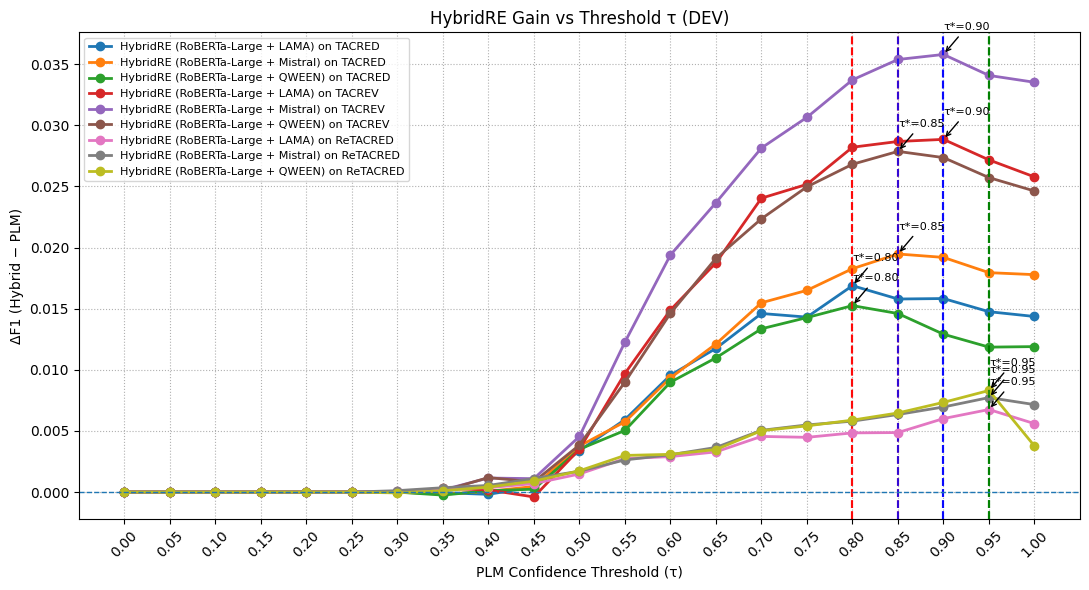

✔ Figure saved to:
  figures/hybridre_threshold_gain_DEV.pdf
  figures/hybridre_threshold_gain_DEV.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scorer
from contextlib import redirect_stdout
import io
from pathlib import Path

# =========================
# CONFIG
# =========================
PLMS = [
    "PLM_ROBERTA-LARGE",
]

SPLIT = "DEV"
DATASETS = ["TACRED","TACREV", "ReTACRED"]
LLMS = ["LAMA", "Mistral","QWEEN"]

THRESHOLDS = np.round(np.arange(0, 1.01, 0.05), 2)

BASE_DIR = Path("3_Final_predictions")
OUT_DIR = Path("figures")
OUT_DIR.mkdir(exist_ok=True)

# Colors for best τ
BEST_TAU_COLORS = {
    "TACRED": "red",
    "ReTACRED": "green",
    "TACREV": "blue",
}

# =========================
# UTILS
# =========================
def silent_score(gold, pred):
    f = io.StringIO()
    with redirect_stdout(f):
        p, r, f1 = scorer.score(gold, pred, verbose=False)
    return p, r, f1


# =========================
# PLOT
# =========================
plt.figure(figsize=(11, 6))

for plm in PLMS:
    for dataset in DATASETS:
        for llm in LLMS:

            file = BASE_DIR / dataset / f"{plm}_{dataset}_{SPLIT}_LORA_{llm}.csv"
            if not file.exists():
                continue

            df = pd.read_csv(file)
            if "LLM_Prediction" not in df.columns:
                continue

            gold = df["True_Labels"].tolist()
            plm_pred = df["Initial_Predictions"].tolist()
            llm_pred = df["LLM_Prediction"].tolist()
            conf = df["Confidence"].tolist()

            # PLM baseline
            _, _, f1_plm = silent_score(gold, plm_pred)

            delta_f1 = []

            for tau in THRESHOLDS:
                hybrid_pred = [
                    p if c >= tau else l
                    for c, p, l in zip(conf, plm_pred, llm_pred)
                ]
                _, _, f1_h = silent_score(gold, hybrid_pred)
                delta_f1.append(f1_h - f1_plm)

            # ---------------------------
            # Curve label (paper-ready)
            # ---------------------------
            label = f"HybridRE (RoBERTa-Large + {llm}) on {dataset}"

            plt.plot(
                THRESHOLDS,
                delta_f1,
                marker="o",
                linewidth=2,
                label=label
            )

            # ---------------------------
            # Best τ
            # ---------------------------
            best_idx = int(np.argmax(delta_f1))
            best_tau = THRESHOLDS[best_idx]
            best_val = delta_f1[best_idx]

            plt.axvline(
                best_tau,
                linestyle="--",
                linewidth=1.5,
                color=BEST_TAU_COLORS[dataset],
                alpha=0.8
            )

            plt.annotate(
                f"τ*={best_tau:.2f}",
                xy=(best_tau, best_val),
                xytext=(best_tau, best_val + 0.002),
                arrowprops=dict(arrowstyle="->"),
                fontsize=8
            )

# =========================
# FINAL STYLE
# =========================
plt.axhline(0, linestyle="--", linewidth=1)

plt.xticks(
    THRESHOLDS,
    [f"{t:.2f}" for t in THRESHOLDS],
    rotation=45
)

plt.xlabel("PLM Confidence Threshold (τ)")
plt.ylabel("ΔF1 (Hybrid − PLM)")
plt.title("HybridRE Gain vs Threshold τ (DEV)")

plt.grid(True, axis="both", linestyle=":")
plt.legend(fontsize=8)
plt.tight_layout()

# =========================
# EXPORT (LaTeX-ready)
# =========================
pdf_path = OUT_DIR / "hybridre_threshold_gain_DEV.pdf"
png_path = OUT_DIR / "hybridre_threshold_gain_DEV.png"

plt.savefig(pdf_path, format="pdf")           # LaTeX / LNCS
plt.savefig(png_path, dpi=300, bbox_inches="tight")  # preview

plt.show()

print(f"✔ Figure saved to:\n  {pdf_path}\n  {png_path}")


In [12]:
import pandas as pd
import numpy as np
import scorer
from contextlib import redirect_stdout
import io
from pathlib import Path

# =========================
# CONFIG
# =========================
PLMS = [
    "PLM_ROBERTA-LARGE",
]

SPLIT = "DEV"
DATASETS = ["TACRED", "TACREV", "ReTACRED"]
LLMS = ["LAMA", "Mistral", "QWEEN"]

THRESHOLDS = np.round(np.arange(0.30, 1.01, 0.05), 2)
BASE_DIR = Path("3_Final_predictions")

# =========================
# UTILS
# =========================
def silent_score(gold, pred):
    f = io.StringIO()
    with redirect_stdout(f):
        p, r, f1 = scorer.score(gold, pred, verbose=False)
    return p, r, f1


# =========================
# COMPUTE + PRINT RESULTS
# =========================
for plm in PLMS:
    print("\n" + "=" * 70)
    print(f"PLM: {plm}")
    print("=" * 70)

    for dataset in DATASETS:
        print(f"\nDataset: {dataset}")
        print("-" * 70)
        print(f"{'LLM':<12}{'tau*':<10}{'Hybrid F1 (%)':<18}{'PLM F1 (%)':<15}{'ΔF1':<10}")
        print("-" * 70)

        for llm in LLMS:

            file = BASE_DIR / dataset / f"{plm}_{dataset}_{SPLIT}_LORA_{llm}.csv"
            if not file.exists():
                continue

            df = pd.read_csv(file)

            required = {"True_Labels", "Initial_Predictions", "Confidence", "LLM_Prediction"}
            if not required.issubset(df.columns):
                continue

            gold = df["True_Labels"].tolist()
            plm_pred = df["Initial_Predictions"].tolist()
            llm_pred = df["LLM_Prediction"].tolist()
            conf = df["Confidence"].tolist()

            # PLM baseline
            _, _, f1_plm = silent_score(gold, plm_pred)

            best_tau = None
            best_f1 = -1.0

            for tau in THRESHOLDS:
                hybrid_pred = [
                    p if c >= tau else l
                    for c, p, l in zip(conf, plm_pred, llm_pred)
                ]
                _, _, f1_h = silent_score(gold, hybrid_pred)

                if f1_h > best_f1:
                    best_f1 = f1_h
                    best_tau = tau

            delta = best_f1 - f1_plm

            print(f"{llm:<12}{best_tau:<10.2f}{best_f1*100:<18.3f}{f1_plm*100:<15.3f}{delta*100:<10.3f}")


PLM: PLM_ROBERTA-LARGE

Dataset: TACRED
----------------------------------------------------------------------
LLM         tau*      Hybrid F1 (%)     PLM F1 (%)     ΔF1       
----------------------------------------------------------------------
LAMA        0.80      75.988            74.300         1.688     
Mistral     0.85      76.247            74.300         1.947     
QWEEN       0.80      75.825            74.300         1.525     

Dataset: TACREV
----------------------------------------------------------------------
LLM         tau*      Hybrid F1 (%)     PLM F1 (%)     ΔF1       
----------------------------------------------------------------------
LAMA        0.90      84.096            81.382         2.713     
Mistral     0.90      84.961            81.382         3.579     
QWEEN       0.85      84.168            81.382         2.786     

Dataset: ReTACRED
----------------------------------------------------------------------
LLM         tau*      Hybrid F1 (%)     

# Reject option

In [ ]:
import pandas as pd
import numpy as np
import scorer
from contextlib import redirect_stdout
import io
from pathlib import Path

def SCORE(y_true, y_pred):
    """
    Equivalent to SCORE(Ŷ(t), {y_i}) in Algorithm 1
    Returns micro-F1
    """
    f = io.StringIO()
    with redirect_stdout(f):
        _, _, f1 = scorer.score(y_true, y_pred, verbose=False)
    return f1



def threshold_selection_reject_option(
    csv_path,
    threshold_grid
):
    """
    Algorithm 1: Threshold Selection under the Reject-Option Framework

    Input:
        - Validation set {(x_i, y_i)}
        - PLM confidence scores C(x_i)
        - PLM predictions ŷ_i^B
        - LLM predictions ŷ_i^L
        - Threshold grid T

    Output:
        - Optimal threshold t*
    """

    # ---------------------------
    # Load validation data
    # ---------------------------
    df = pd.read_csv(csv_path)

    y_true = df["True_Labels"].tolist()
    y_plm  = df["Initial_Predictions"].tolist()
    y_llm  = df["LLM_Prediction"].tolist()
    C      = df["Confidence"].tolist()

    # ---------------------------
    # Line 1: Initialize F ← ∅
    # Stores (t, F1_t) pairs
    # ---------------------------
    F = []

    # ---------------------------
    # Line 2: for each threshold t ∈ T
    # ---------------------------
    for t in threshold_grid:

        # ---------------------------
        # Line 3: Initialize Ŷ(t) ← ∅
        # ---------------------------
        Y_hat_t = []

        # ---------------------------
        # Line 4: for each instance i = 1..N
        # ---------------------------
        for i in range(len(y_true)):

            # ---------------------------
            # Line 5–9: Reject option
            # ---------------------------
            if C[i] >= t:
                # Line 6: Accept PLM prediction
                y_hat = y_plm[i]
            else:
                # Line 8: Reject and escalate to LLM
                y_hat = y_llm[i]

            # Line 10: Append prediction
            Y_hat_t.append(y_hat)

        # ---------------------------
        # Line 12: Compute micro-F1
        # ---------------------------
        F1_t = SCORE(y_true, Y_hat_t)

        # ---------------------------
        # Line 13: Append (t, F1_t) to F
        # ---------------------------
        F.append((t, F1_t))

    # ---------------------------
    # Line 15: t* ← argmax_t F1_t
    # ---------------------------
    t_star, best_f1 = max(F, key=lambda x: x[1])

    # Line 16: return t*
    return t_star, best_f1, F


In [ ]:
# =========================
# CONFIG
# =========================
DATASET = "ReTACRED"
SPLIT = "DEV"
PLM = "PLM_ROBERTA-LARGE"
LLMS = ["LAMA", "Mistral", "QWEEN"]

THRESHOLD_GRID = np.round(np.arange(0.0, 1.01, 0.05), 2)

BASE_DIR = Path("3_Final_predictions") / DATASET

print("\n" + "=" * 80)
print("Algorithm 1 — Threshold Selection (Reject-Option)")
print("=" * 80)

for llm in LLMS:

    csv_file = BASE_DIR / f"{PLM}_{DATASET}_{SPLIT}_LORA_{llm}.csv"
    if not csv_file.exists():
        print(f"[SKIP] {csv_file.name}")
        continue

    t_star, best_f1, all_scores = threshold_selection_reject_option(
        csv_file,
        THRESHOLD_GRID
    )

    print(f"\nLLM: {llm}")
    print(f"Optimal threshold τ*: {t_star:.2f}")
    print(f"Hybrid F1 @ τ*:       {best_f1:.3%}")



Algorithm 1 — Threshold Selection (Reject-Option)

LLM: LAMA
Optimal threshold τ*: 0.95
Hybrid F1 @ τ*:       91.600%

LLM: Mistral
Optimal threshold τ*: 0.95
Hybrid F1 @ τ*:       91.697%

LLM: QWEEN
Optimal threshold τ*: 0.95
Hybrid F1 @ τ*:       91.755%


In [ ]:
# =========================
# CONFIG
# =========================
DATASET = "TACRED"
SPLIT = "DEV"
PLM = "PLM_ROBERTA-LARGE"
LLMS = ["LAMA", "Mistral", "QWEEN"]

THRESHOLD_GRID = np.round(np.arange(0.0, 1.01, 0.05), 2)

BASE_DIR = Path("3_Final_predictions") / DATASET

print("\n" + "=" * 80)
print("Algorithm 1 — Threshold Selection (Reject-Option)")
print("=" * 80)

for llm in LLMS:

    csv_file = BASE_DIR / f"{PLM}_{DATASET}_{SPLIT}_LORA_{llm}.csv"
    if not csv_file.exists():
        print(f"[SKIP] {csv_file.name}")
        continue

    t_star, best_f1, all_scores = threshold_selection_reject_option(
        csv_file,
        THRESHOLD_GRID
    )

    print(f"\nLLM: {llm}")
    print(f"Optimal threshold τ*: {t_star:.2f}")
    print(f"Hybrid F1 @ τ*:       {best_f1:.3%}")



Algorithm 1 — Threshold Selection (Reject-Option)

LLM: LAMA
Optimal threshold τ*: 0.80
Hybrid F1 @ τ*:       75.988%

LLM: Mistral
Optimal threshold τ*: 0.85
Hybrid F1 @ τ*:       76.247%

LLM: QWEEN
Optimal threshold τ*: 0.80
Hybrid F1 @ τ*:       75.825%
